In [118]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from deviation import all_devices

In [ ]:
def retrieve_data(filenames:list) -> dict:
    raw_datas = {}
    for i in filenames:
        try:
            temp_data=[]
            with open(f"./Measures/{i}", "r") as File:
                # raw_datas.append(list(map(float, File.readlines().replace(",", "."))))
                for line in File.readlines():
                    temp_data.append(float(line.strip().replace("\n", "").replace(",", ".")))
            raw_datas[i[:-4]] = temp_data
            # print(temp_data)
            # exit(0)
        except FileNotFoundError as e:
            print(f"Error:{e}")
    return raw_datas

In [120]:
# filenames = ["DC_voltage_measure.csv", "R1_resistance_measure.csv", "R2_resistance_measure.csv", "Gained_DC_voltage_measure.csv"]
filenames = ["DC_voltage_measure.txt", "R1_resistance_measure.txt", "R2_resistance_measure.txt", "Gained_DC_voltage_measure.txt"]
# filenames = ["dc_1.txt", "r1_1.txt", "r2_1.txt", "ou_1.txt"]

csv_data = retrieve_data(filenames)

# print(csv_data.keys())

In [ ]:
def print_all_data(raw_datas:dict) -> None:
    for i in raw_datas:

        raw_data = raw_datas[i]
        print(i)

        stats = {}
        stats["Размер выборки"] = len(raw_data)
        stats["Минимальное значение"] = min(raw_data)
        stats["Максимальное значение"] = max(raw_data)
        stats["Среднекватратичное значение"] = np.std(raw_data)
        stats["Среднееарифметическое"] = sum(raw_data)/len(raw_data)
        stats["точечная оценка среднеквадратического отклонения среднего арифметического"] = np.std(raw_data, ddof=1) / np.sqrt(len(raw_data))
        stats["sqrt(1/n-1 * sum (xi - xavg)^2)"] = np.std(raw_data, ddof=1)
        stats["1/n * sum (xi)^2 - xavg^2)"] = sum(raw_data**2) / len(raw_data) - (sum(raw_data)/len(raw_data))**2
        stats["Медианное значение"] = np.median(raw_data)
        stats["Среднеквадратическое значение среднего арифметического"] = stats["Среднекватратичное значение"] / len(raw_data)**.5
        stats["Выборочная дисперсия"] = np.var(raw_data)
        stats["Коэффициент асимметрии"] = sp.stats.skew(raw_data)
        stats["Коэффициент эксцесса"] = sp.stats.kurtosis(raw_data)

        for j in stats.keys():
            print(f"{j}: {stats[j]}")

        
        

        

In [122]:
print_all_data(csv_data)

DC_voltage_measure
Размер выборки: 1001
Минимальное значение: 0.54172
Максимальное значение: 1.00057
Среднекватратичное значение: 0.02636013838688168
Среднееарифметическое: 0.9971855944055931
точечная оценка среднеквадратического отклонения среднего арифметического: 0.0008335807673978289
sqrt(1/n-1 * sum (xi - xavg)^2): 0.026373315162704306
Медианное значение: 1.0
Среднеквадратическое значение среднего арифметического: 0.0008331642893466514
Выборочная дисперсия: 0.0006948568957755532
Коэффициент асимметрии: -12.360059200113545
Коэффициент эксцесса: 168.34201617848444
R1_resistance_measure
Размер выборки: 2000
Минимальное значение: 6812.17
Максимальное значение: 6813.6
Среднекватратичное значение: 0.11020725520582494
Среднееарифметическое: 6812.498529999894
точечная оценка среднеквадратического отклонения среднего арифметического: 0.0024649254509498423
sqrt(1/n-1 * sum (xi - xavg)^2): 0.11023481735586343
Медианное значение: 6812.54
Среднеквадратическое значение среднего арифметического:

### Правило Стерджеса (количество интервалов в зависимости от размера выборки)
$ r = 1 + \lfloor log_2n \rfloor$


### Функция, которая строит гистограммы значений в зависимости от числа наблюдаемых значений, а также накладывает теоретический график нормального распределения, который масштабируется под количество элементов выборки

In [123]:
def make_plot(values:list, name:str, theoretical_norm:bool=True) -> None:
    r = int(1 + np.floor(np.log2(len(values))))
    fig, ax = plt.subplots(1)
    if theoretical_norm:
        x_theor = np.linspace(min(values), max(values), 100)
        y_theor = sp.stats.norm.pdf(x_theor, np.mean(values), np.std(values))
        n, bins, patches = ax.hist(values, bins=r, alpha=.6, color="blue", edgecolor="black")
        ax.plot(x_theor, y_theor * (bins[1] - bins[0]) * len(values), color="red", alpha=.6)
        for i, v in enumerate(bins[:-1]):
            text_pos = v + (bins[i+1] - v)/2
            ax.text(text_pos, n[i] + 5, f"{int(n[i])}", ha="center", va="bottom", fontsize=10)
        
    else:
        ax.hist(values, bins=r, alpha=.6, color="blue", edgecolor="black")
    fig.gca().ticklabel_format(axis='x', useOffset=False)
    ax.axvline(x=np.median(values), color="red", alpha=.7)
    ax.set_title(name, size=20)
    ax.grid(alpha=.3)
    fig.set_size_inches(12, 8)
    fig.savefig(f"./Measurements/{name}.png", dpi=300, bbox_inches="tight") 

DC_voltage_measure: n = 1001
R1_resistance_measure: n = 2000
R2_resistance_measure: n = 100
Gained_DC_voltage_measure: n = 100


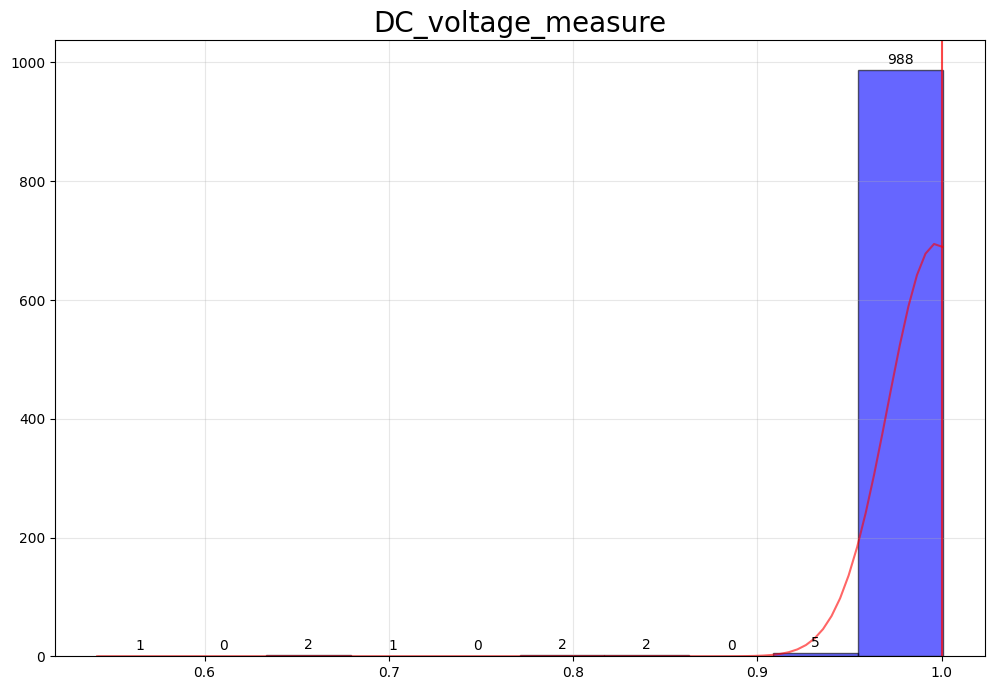

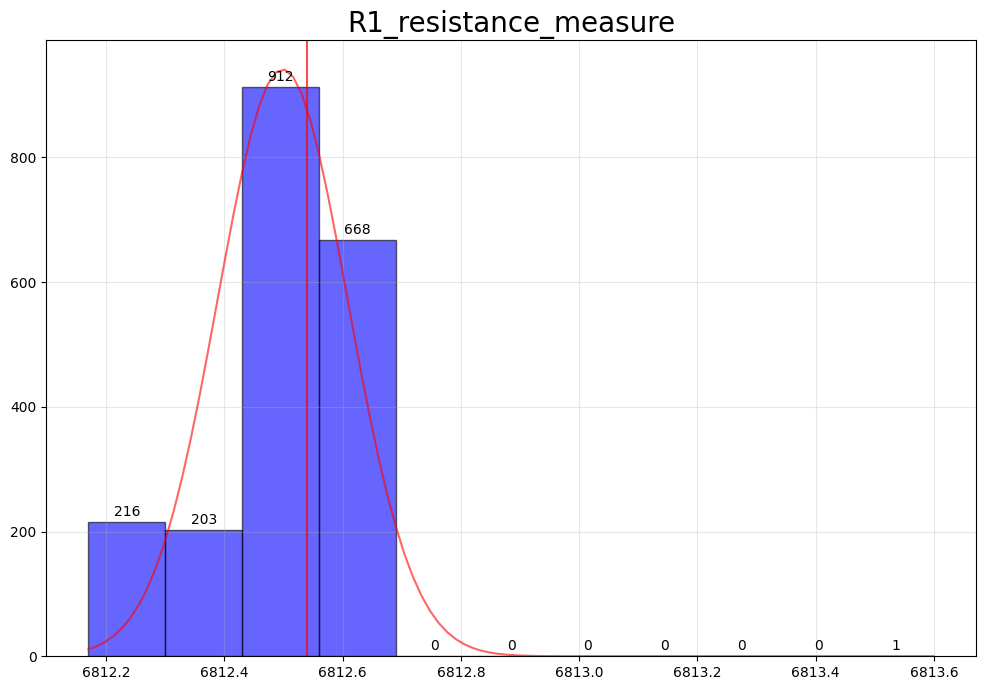

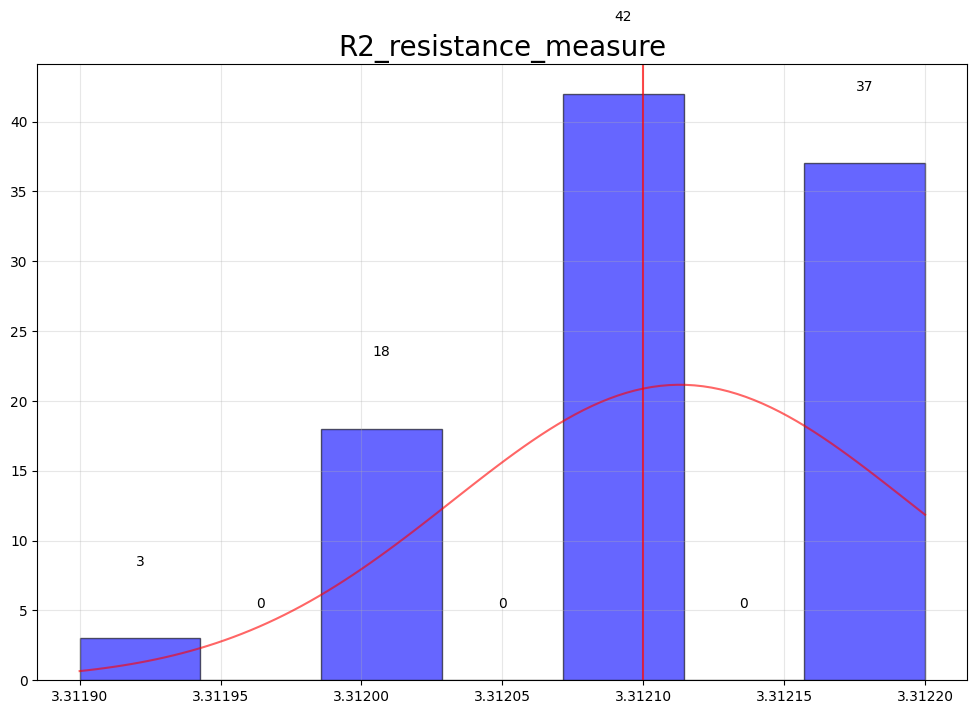

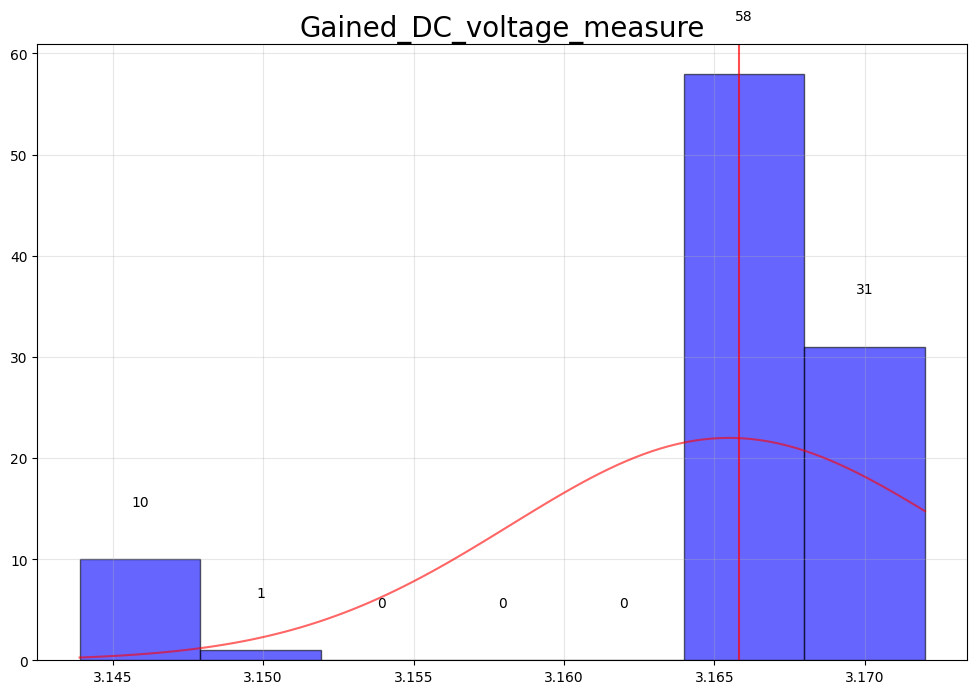

In [124]:
for i in csv_data:
    make_plot(csv_data[i], i)
    print(f"{i}: n = {len(csv_data[i])}")

### В качестве числовой характеристики типа распределения экспериментальных данных принимаем значение κ, вычисляемое по формуле:

### $ к = \frac{\sum_{i=1}^{n}(x_i - \overline{x})^4}{nS^4} $

#### где S – выборочное СКО.

In [125]:
def calculate_k(values: list) -> float:
    S = np.std(values, ddof=1)
    M = np.mean(values)
    summ = np.sum((np.array(values) - M)**4)
    k = summ / (len(values) * S**4)
    return k

In [126]:
def what_should_be_used(k:float) -> None:
    if k <= 1.8:
        print("распределение не одномодальное и оценка по данной методике невозможна")
    elif 1.8 <= k <= 2.5:
        print("в качестве оценки используется среднее максимального и минимального значения выборки")
    elif 2.5 <= k <= 4:
        print("в качестве оценки используется выборочное среднее арифметическое")
    elif 4 <= k:
        print("в качестве оценки используется медианное значение")

In [127]:
for i in csv_data:
    k = calculate_k(csv_data[i])
    print(f"{i}: {k = :.5f}")
    what_should_be_used(k)


DC_voltage_measure: k = 170.99985
в качестве оценки используется медианное значение
R1_resistance_measure: k = 7.75832
в качестве оценки используется медианное значение
R2_resistance_measure: k = 2.58061
в качестве оценки используется выборочное среднее арифметическое
Gained_DC_voltage_measure: k = 5.62281
в качестве оценки используется медианное значение


### Функция для вычитания системной погрешности

In [128]:
def substract_methodic_deviation(values:list, deviation:str, measure_range:float) -> list:
    distinct_value_deviation, range_deviation = map(float, deviation.split("+"))

    new_values = []
    for i in values:
        new_values.append(i - (distinct_value_deviation * i + range_deviation * measure_range))
    
    return new_values


In [129]:
#"DC_voltage_measure.csv", "R1_resistance_measure.csv", "R2_resistance_measure.csv", "Gained_DC_voltage_measure.csv"

corrected_data = {}
corrected_data["DC_voltage_measure"] = substract_methodic_deviation(csv_data["DC_voltage_measure"], 
                                                                    all_devices["Multimeter"]["Voltage"]["2V"]["normal_temp"],
                                                                    2.)
corrected_data["R1_resistance_measure"] = substract_methodic_deviation(csv_data["R1_resistance_measure"], 
                                                                    all_devices["Multimeter"]["Resistance"]["20kOhm"]["normal_temp"],
                                                                    2. * 10**4)
corrected_data["R2_resistance_measure"] = substract_methodic_deviation(csv_data["R2_resistance_measure"], 
                                                                    all_devices["Multimeter"]["Resistance"]["200Ohm"]["normal_temp"],
                                                                    2. * 10**2)
corrected_data["Gained_DC_voltage_measure"] = substract_methodic_deviation(csv_data["Gained_DC_voltage_measure"], 
                                                                    all_devices["Multimeter"]["Voltage"]["20V"]["normal_temp"],
                                                                    20.)


### Формула для вычисления критического значение коэффициента граббса, для исключения выбросов

### $ t_{\text{critical}} = t_{1 - \frac{\alpha}{2N}, \, N-2} $
### $ G_{\text{critical}} = \frac{(N - 1) \cdot t_{\text{critical}}}{\sqrt{N} \cdot \sqrt{N - 2 + t_{\text{critical}}^2}} $

In [130]:
def drop_misses_GT(values:list, alpha=.05) -> list:
    new_values = sorted(values.copy())
    
    while 1:
        N = len(new_values)
        M = np.mean(new_values)
        S = np.std(new_values, ddof=1)
        G1 = abs(new_values[-1] - M) / S
        G2 = abs(M - new_values[0]) / S
        t = sp.stats.t.ppf(1 - alpha/(2 * N), N - 2)
        Gt = ((N - 1) * t)/(N**.5 * (N - 2 + t**2)**.5)
        # print(f"{new_values[0]} < {G2}")
        # print(f"{new_values[-1]} > {G1}")
        if G1 > Gt:
            new_values = new_values[:-1]
        elif G2 > Gt:
            new_values = new_values[1:]
        else:
            break
    return new_values

In [131]:
def drop_misses_3_sigmas(values:list) -> tuple:
    new_values = sorted(values.copy())
    values_range = [min(new_values), max(new_values)]
    dropped_values = []
    while 1:
        N = len(new_values)
        M = np.mean(new_values)
        S = np.std(new_values, ddof=1)
        if new_values[-1] > M + 3 * S:
            dropped_values.append(new_values[-1])
            new_values = new_values[:-1]  
        elif new_values[0] < M - 3 * S:
            dropped_values.append(new_values[0])
            new_values = new_values[1:]
        else:
            break
    return (new_values, values_range, sorted(dropped_values))

DC_voltage_measure: n = 1001, n2 = 957
Диапазон: [0.54172, 1.00057]
Исключённые промахи: [0.54172, 0.64987, 0.66478, 0.69476, 0.79058, 0.80569, 0.82412, 0.84885, 0.92208, 0.92442, 0.93568, 0.93652, 0.938, 0.96652, 0.96829, 0.96925, 0.9736, 0.9777, 0.97931, 0.98189, 0.98505, 0.9867, 0.98786, 0.98814, 0.99029, 0.99148, 0.99247, 0.99276, 0.99414, 0.99548, 0.99581, 0.99665, 0.99787, 0.99803, 0.99819, 0.99822, 0.99826, 0.99827, 0.99841, 0.99849, 0.99851, 0.99859, 0.99859, 0.99942]
R1_resistance_measure: n = 2000, n2 = 1998
Диапазон: [6812.17, 6813.6]
Исключённые промахи: [6812.17, 6813.6]
R2_resistance_measure: n = 100, n2 = 100
Диапазон: [3.3119, 3.3122]
Исключённые промахи: []
Gained_DC_voltage_measure: n = 100, n2 = 100
Диапазон: [3.1439, 3.172]
Исключённые промахи: []


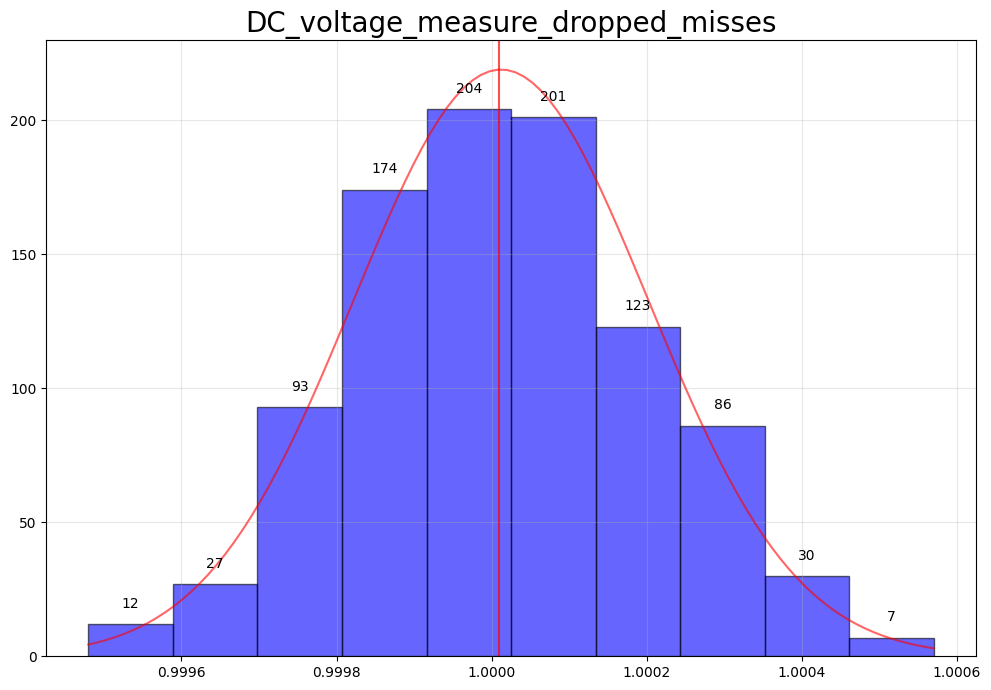

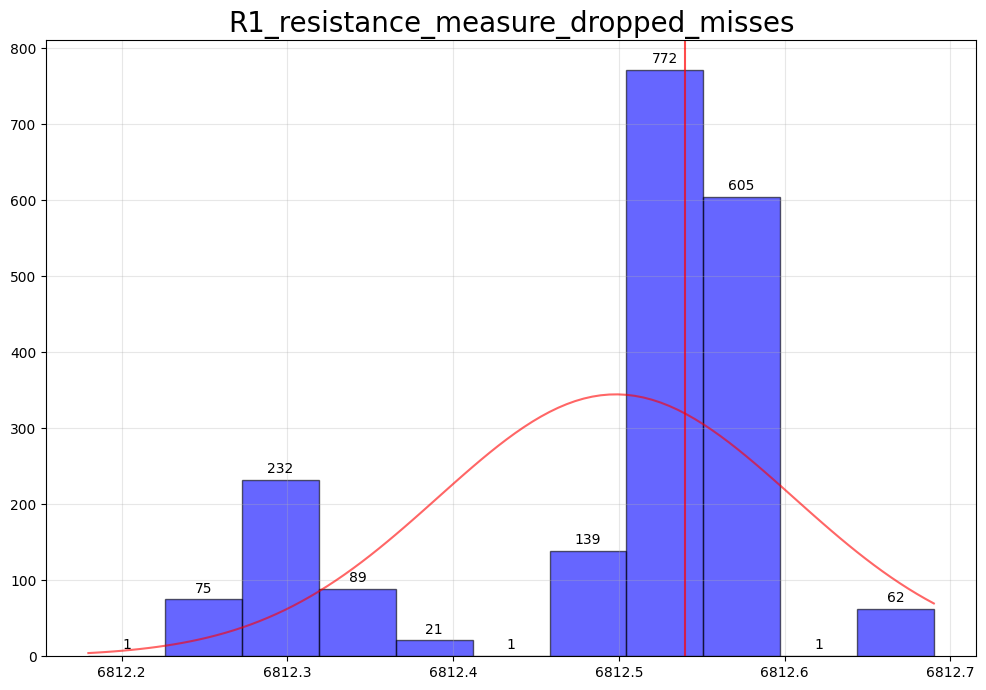

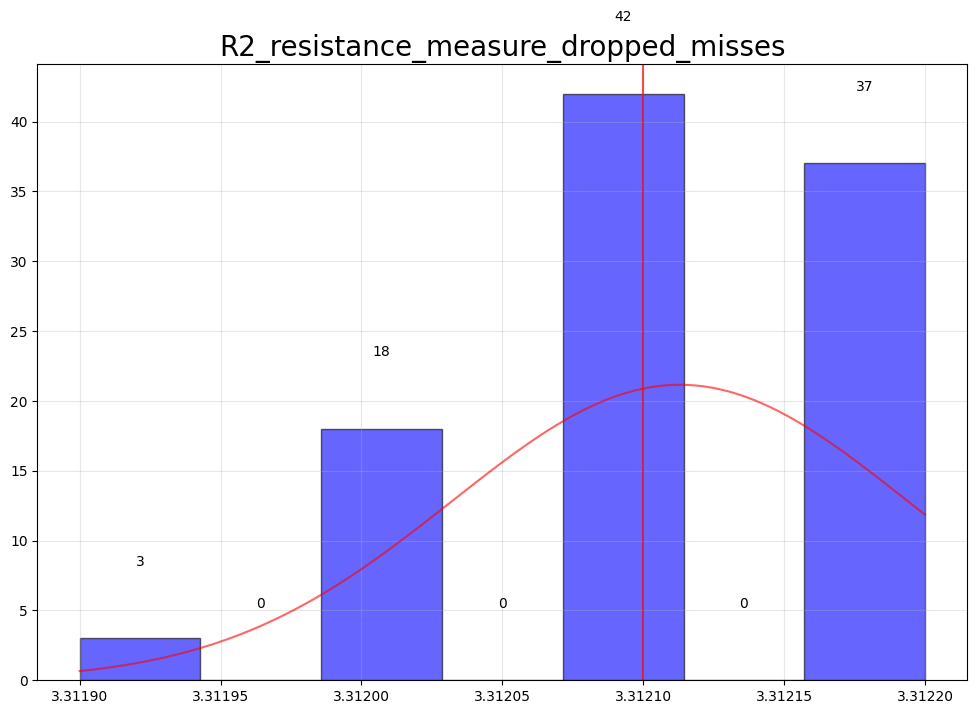

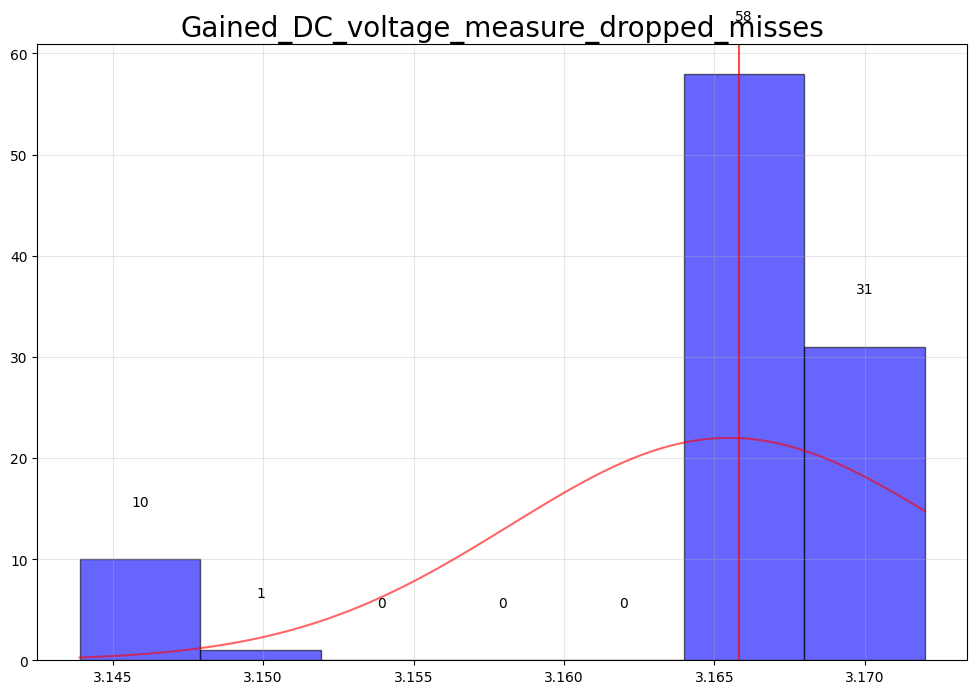

In [132]:
for i in csv_data:
    func_values = drop_misses_3_sigmas(csv_data[i]) 
    new_vals = func_values[0]
    print(f"{i}: n = {len(csv_data[i])}, n2 = {len(new_vals)}")
    print(f"Диапазон: {func_values[1]}")
    print(f"Исключённые промахи: {func_values[2]}")
    make_plot(new_vals, i + "_dropped_misses")

### Посторение графиков по выборкам с исключённой погрешностью и исключёнными выбросами

DC_voltage_measure: n = 1001, n2 = 957
Диапазон: [0.5275942, 0.97956145]
Исключённые промахи: [0.5275942, 0.6341219499999999, 0.6488083, 0.6783386, 0.7727212999999999, 0.78760465, 0.8057582, 0.83011725, 0.9022488, 0.9045537, 0.9156447999999999, 0.9164722000000001, 0.9179299999999999, 0.9460222, 0.94776565, 0.9487112499999999, 0.9529960000000001, 0.9570345, 0.95862035, 0.9611616500000001, 0.96427425, 0.9658995, 0.9670421, 0.9673179000000001, 0.96943565, 0.9706078, 0.97158295, 0.9718686, 0.9732279, 0.9745478000000001, 0.97487285, 0.97570025, 0.97690195, 0.97705955, 0.97721715, 0.9772467, 0.9772861, 0.97729595, 0.97743385, 0.97751265, 0.97753235, 0.97761115, 0.97761115, 0.9784286999999999]
R1_resistance_measure: n = 2000, n2 = 1998
Диапазон: [6615.9266, 6617.328]
Исключённые промахи: [6615.9266, 6617.328]
R2_resistance_measure: n = 100, n2 = 100
Диапазон: [2.212543, 2.212834]
Исключённые промахи: []
Gained_DC_voltage_measure: n = 100, n2 = 100
Диапазон: [3.0167414999999997, 3.04442]
Исклю

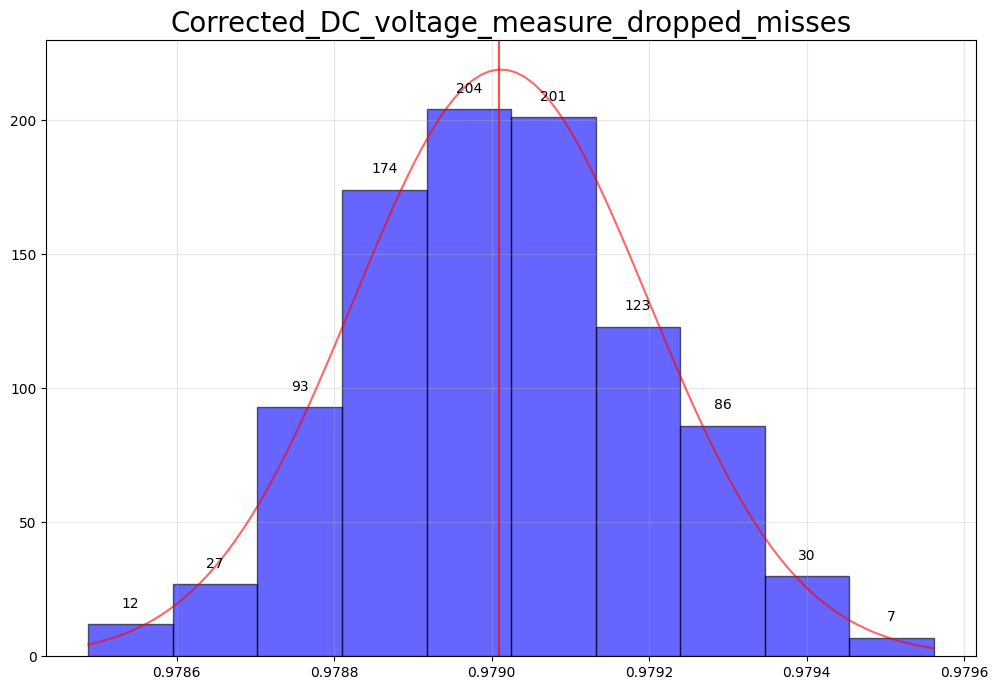

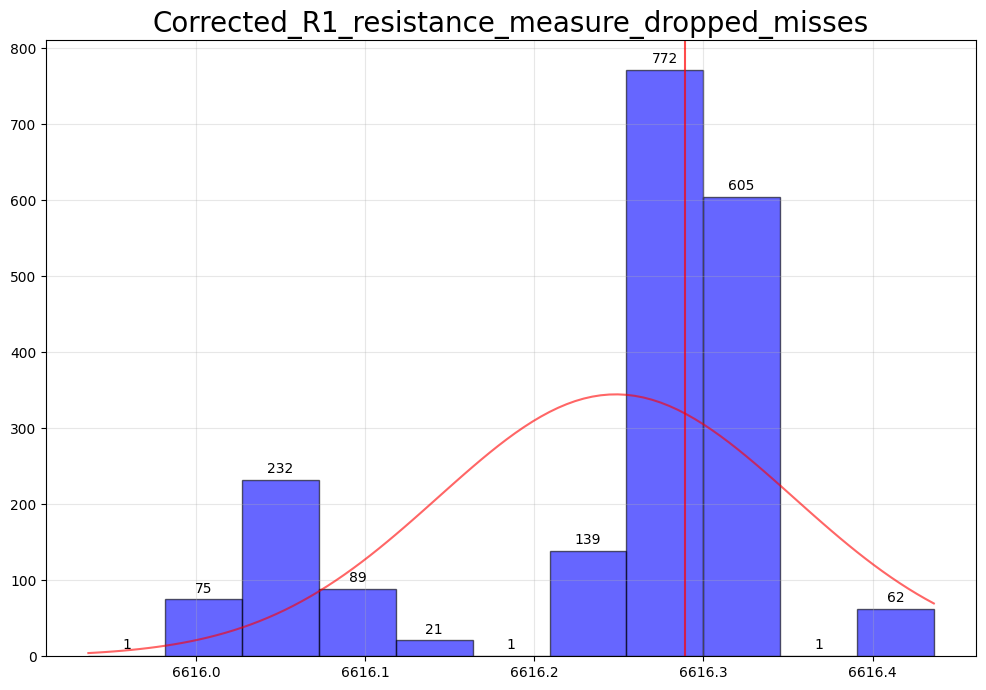

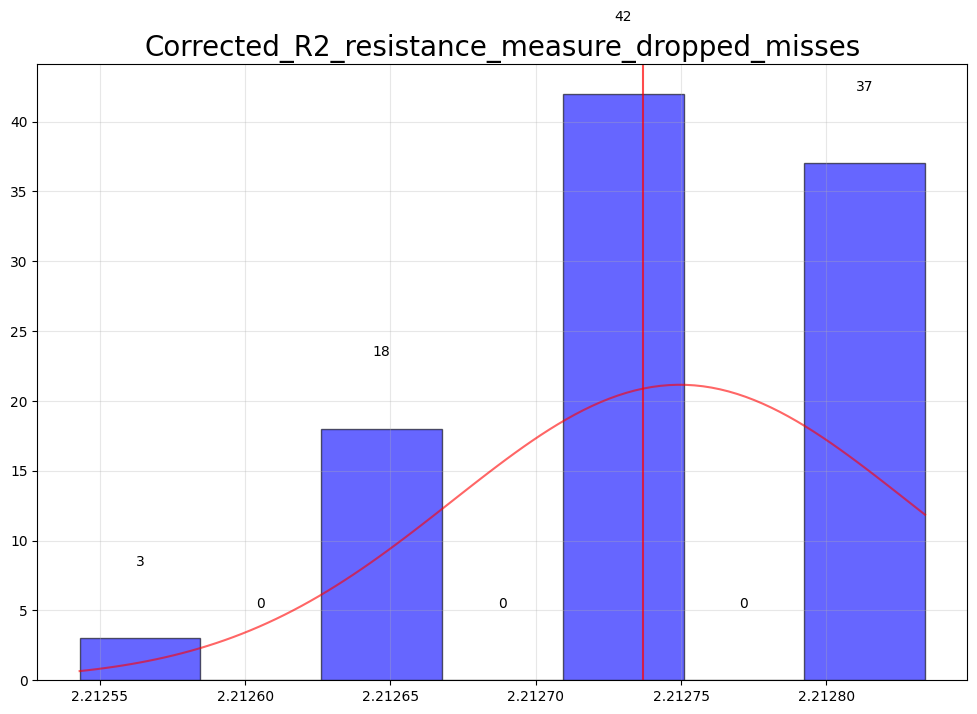

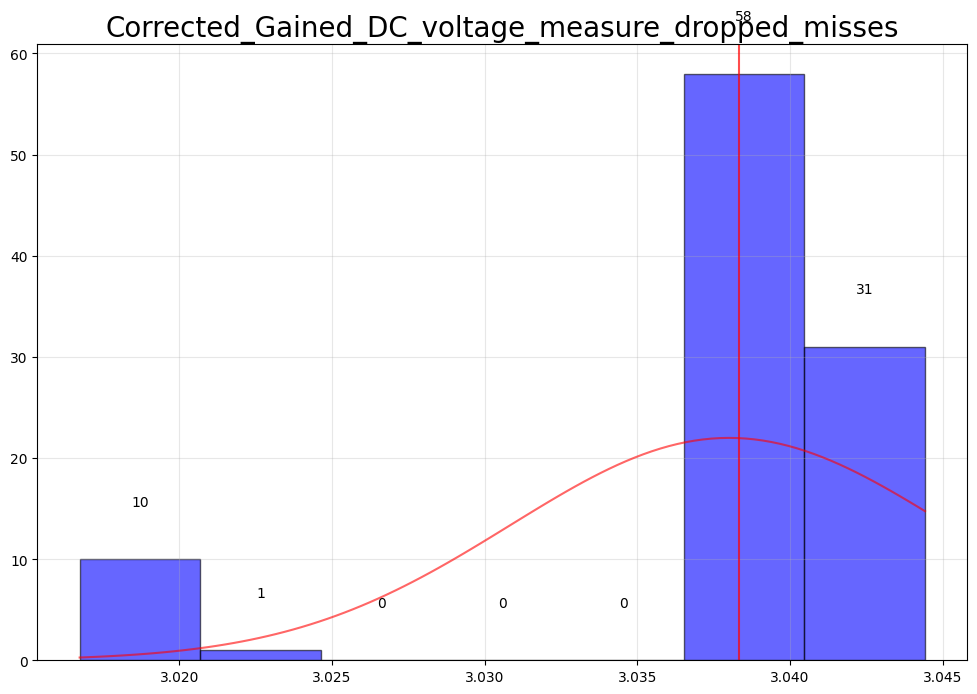

In [133]:
for i in corrected_data:
    func_values = drop_misses_3_sigmas(corrected_data[i]) 
    new_vals = func_values[0]
    print(f"{i}: n = {len(corrected_data[i])}, n2 = {len(new_vals)}")
    print(f"Диапазон: {func_values[1]}")
    print(f"Исключённые промахи: {func_values[2]}")
    make_plot(new_vals, "Corrected_" + i + "_dropped_misses")

In [134]:
print_all_data(corrected_data)

DC_voltage_measure
Размер выборки: 1001
Минимальное значение: 0.5275942
Максимальное значение: 0.97956145
Среднекватратичное значение: 0.025964736311078457
Среднееарифметическое: 0.9762278104895097
точечная оценка среднеквадратического отклонения среднего арифметического: 0.0008210770558868614
sqrt(1/n-1 * sum (xi - xavg)^2): 0.02597771543526374
Медианное значение: 0.979
Среднеквадратическое значение среднего арифметического: 0.0008206668250064517
Выборочная дисперсия: 0.0006741675317038362
Коэффициент асимметрии: -12.360059200113529
Коэффициент эксцесса: 168.3420161784842
R1_resistance_measure
Размер выборки: 2000
Минимальное значение: 6615.9266
Максимальное значение: 6617.328
Среднекватратичное значение: 0.10800311010172427
Среднееарифметическое: 6616.24855939997
точечная оценка среднеквадратического отклонения среднего арифметического: 0.0024156269419311994
sqrt(1/n-1 * sum (xi - xavg)^2): 0.10803012100876198
Медианное значение: 6616.2892
Среднеквадратическое значение среднего арифм

In [135]:
corrected_data_dropped_misses = {}

for i in corrected_data:
    corrected_data_dropped_misses[i] = drop_misses_3_sigmas(corrected_data[i])[0] 

<h3> Проверка гипотезы о нормальном распределении по критерию согласия Пирсона </h3>

<div style="font-size:23px">

$$
\chi^2 = \sum_{j=1}^{r}\frac{(O_j - E_j)^2}{E_j}
$$
$ E_j $ - ожидаемое число попаданий в этот
же интервал исходя из выдвинутой гипотезы
$$
E_j = n \cdot l \cdot f(x_{j0})
$$

$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac12(\frac{x-\mu}{\sigma})^2}
$$

In [136]:
def norm_pdf(x, std, mean):
    return 1/(std * (2 * np.pi)**.5) * np.e**(-1/2 * ((x - mean)/std)**2)

In [137]:
def chi2(Oj, Ej):
    return np.sum((Oj - Ej)**2 / Ej)

In [138]:
def check_hypothethis(values, alpha=.05):
    r = int(1 + np.floor(np.log2(len(values))))
    n, bins, patches = plt.hist(values, bins=r)
    M = np.mean(values)
    S = np.std(values, ddof=1)
    chi2q = sp.stats.chi2.ppf(1 - alpha, len(bins) - 1 - 2)
    print(chi2q)
    print(f"|{'Номер интервала j':^21}|{'Середина интервала xj0':^24}|{'Наблюдаемое число попаданий в интервал Oj':^43}|" + 
      f"{'Оцениваемое число попоаданий в интервал Ej':^44}|{'Значение статистики хи^2':^26}|{'Гипотеза':^10}|")
    
    chi2_stat = 0
    observed_list = []
    expected_list = []
    for i, v in enumerate(bins[:-1]):
        # Середина интервала
        xj0 = (bins[i] + bins[i+1]) / 2
        
        # Длина интервала
        l = bins[i+1] - bins[i]
        
        # Наблюдаемое число попаданий
        Oj = n[i]
        
        # Ожидаемое число попаданий
        Ej = len(values) * l * norm_pdf(xj0, S, M)
        
        # Вклад интервала в статистику хи-квадрат
        chi2_j = (Oj - Ej)**2 / Ej if Ej > 0 else 0
        chi2_stat += chi2_j
        
        observed_list.append(Oj)
        expected_list.append(Ej)
        
        print(f"|{i+1:^21}|{xj0:^24.4f}|{Oj:^43}|{Ej:^44.4f}|{chi2_j:^26.4f}|{chi2_j < chi2q:^10}|")


DC_voltage_measure
15.507313055865453
|  Номер интервала j  | Середина интервала xj0 | Наблюдаемое число попаданий в интервал Oj | Оцениваемое число попоаданий в интервал Ej | Значение статистики хи^2 | Гипотеза |
|          1          |         0.9785         |                   12.0                    |                   9.3738                   |          0.7358          |    1     |
|          2          |         0.9786         |                   27.0                    |                  33.5133                   |          1.2659          |    1     |
|          3          |         0.9788         |                   93.0                    |                  86.2856                   |          0.5225          |    1     |
|          4          |         0.9789         |                   174.0                   |                  159.9843                  |          1.2279          |    1     |
|          5          |         0.9790         |                   204.0          

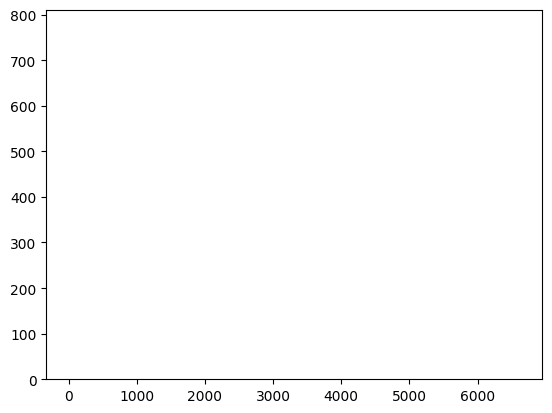

In [139]:
for i in corrected_data_dropped_misses:
    print(i)
    check_hypothethis(corrected_data_dropped_misses[i])

### Функция для нахождения доверительных интервалов
<div style="font-size:23px">

$$
P\{|x - \mu| \leq t\sigma\} \geq 1 - \frac{1}{t^2}
$$

In [140]:
def conf_interval(values, alpha=.05):
    M = np.mean(values)
    S = np.std(values, ddof=1)
    t = 1 / (1 - alpha)**.5
    lower = M - t * S
    upper = M + t * S
    bound = t * S / len(values)**.5
    return (lower, upper, bound)

### Нахождение доверительных интервалов для каждой выборки 

### Измеренное значение: $ \overline{x} \pm \Delta(\alpha) $

In [141]:
# У нас нормальное только DC !!!
# Остальные надо по Чебышеву
for i in corrected_data_dropped_misses:
    print(i)
    interval = conf_interval(corrected_data_dropped_misses[i]) 
    print(interval[:-1], interval[1] - interval[0])
    print(f"epsilon(a) = {interval[-1]}")
    print(f"measured value: {np.mean(corrected_data_dropped_misses[i])} ± {interval[-1]}")
    print()

DC_voltage_measure
(0.9788195579088376, 0.9792040532719356) 0.00038449536309803634
epsilon(a) = 6.2144849722408755e-06
measured value: 0.9790118055903866 ± 6.2144849722408755e-06

R1_resistance_measure
(6616.140346718073, 6616.356013842488) 0.2156671244156314
epsilon(a) = 0.0024124382743628877
measured value: 6616.24818028028 ± 0.0024124382743628877

R2_resistance_measure
(2.2126687782137306, 2.212830441786269) 0.00016166357253855068
epsilon(a) = 8.08317862690958e-06
measured value: 2.21274961 ± 8.08317862690958e-06

Gained_DC_voltage_measure
(3.030604455975194, 3.0454009940248055) 0.014796538049611563
epsilon(a) = 0.0007398269024805574
measured value: 3.0380027249999997 ± 0.0007398269024805574

